# Business Analytics Dataset - EDA

In [1]:
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import matplotlib.pyplot as plt
import seaborn as sns

import math

/kaggle/input/datasets/dilgekarakas/exmox-dataset/Business_Analytics_Dataset_10000_Rows.csv


In [2]:
df = pd.read_csv('../data/Business_Analytics_Dataset_10000_Rows.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df["Day_of_Week"] = df["Order_Date"].dt.day_name()
df["Day_of_Month"] = df["Order_Date"].dt.day

In [3]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Order_ID,10000.0,5000.5,1.0,2500.75,5000.5,7500.25,10000.0,2886.89568
Order_Date,10000,2024-06-30 09:16:07.680000,2024-01-01 00:00:00,2024-03-31 00:00:00,2024-06-29 00:00:00,2024-09-28 00:00:00,2024-12-31 00:00:00,NaN
Quantity,10000.0,5.5143,1.0,3.0,5.0,8.0,10.0,2.86451
Unit_Price,10000.0,255.505222,10.0,132.7775,254.995,377.8925,499.94,140.832874
Discount_Rate,10000.0,0.150272,0.0,0.08,0.15,0.23,0.3,0.086818
Revenue,10000.0,1195.241948,8.59,396.3,924.365,1775.84,4972.1,979.590244
Cost,10000.0,776.29218,5.74,255.5925,595.48,1141.3325,3911.52,651.473171
Profit,10000.0,418.949768,1.97,131.785,311.395,606.845,2292.42,368.418447
Day_of_Month,10000.0,15.9618,1.0,8.0,16.0,24.0,31.0,8.791511


The dates range from the beginning of 2024 to the end of 2024. There are 10,000 order records.

In [4]:
data = df.copy()
data["expected_revenue"] = data["Quantity"] * data["Unit_Price"] * (1 - data["Discount_Rate"])
data["revenue_error"] = data["Revenue"] - data["expected_revenue"]
data["revenue_error_abs"] = data["revenue_error"].abs()

print("Pct within $0.05:", (data["revenue_error_abs"] <= 0.05).mean() * 100)

Pct within $0.05: 100.0


In [5]:
display(df.groupby('Product_Category')['Profit'].describe())

display(df.groupby('Customer_Segment')['Profit'].describe())

display(df.groupby('Payment_Method')['Profit'].describe())

,count,mean,std,min,25%,50%,75%,max
Product_Category,,,,,,,,
Beauty,1996.0,423.730586,367.989625,1.97,139.6725,318.235,615.500,2292.42
Clothing,2008.0,406.087854,361.650972,2.75,126.8875,293.610,580.850,1977.04
Electronics,1991.0,429.021873,372.232971,2.79,136.5000,321.510,622.700,2132.88
Home & Kitchen,2008.0,419.849114,377.807361,4.72,126.4200,304.510,609.075,2079.54
Sports,1997.0,416.157962,362.114702,3.27,129.6600,319.760,601.320,2103.84


,count,mean,std,min,25%,50%,75%,max
Customer_Segment,,,,,,,,
Consumer,3295.0,422.710537,370.327263,3.97,135.140,323.03,603.290,2204.09
Corporate,3316.0,422.334201,367.471635,1.97,134.435,312.66,613.265,2292.42
Home Office,3389.0,411.981779,367.490782,2.75,126.120,296.68,602.890,2059.94


,count,mean,std,min,25%,50%,75%,max
Payment_Method,,,,,,,,
Cash on Delivery,2017.0,421.926039,374.854405,1.97,128.1600,309.760,610.070,2132.88
Credit Card,1963.0,421.033698,371.698705,3.27,131.7500,315.480,605.250,2292.42
Debit Card,2074.0,414.285121,362.915484,5.22,133.5825,305.135,600.445,2059.94
Net Banking,1935.0,414.055132,361.107754,3.91,128.8200,314.900,601.965,2204.09
UPI,2011.0,423.450865,371.534556,3.54,136.3900,313.450,617.320,2079.54


When we look at the population distributions, we see that none of the categories are distinct from each other and they are evenly distributed. There is also no differentiation in averages, 75th quantile, median, etc. This indicates that the data is synthetic. Here we see a perfectly balanced dataset. We observe almost the same populations in every grouped unit.

In [6]:
cols = ["Region", "Product_Category", "Customer_Segment", "Payment_Method"]

for col in cols:
    print(f"\n--- {col} ({df[col].nunique()} unique) ---")
    for val in sorted(df[col].dropna().unique()):
        print(f"• {val}")


--- Region (4 unique) ---
• East
• North
• South
• West

--- Product_Category (5 unique) ---
• Beauty
• Clothing
• Electronics
• Home & Kitchen
• Sports

--- Customer_Segment (3 unique) ---
• Consumer
• Corporate
• Home Office

--- Payment_Method (5 unique) ---
• Cash on Delivery
• Credit Card
• Debit Card
• Net Banking
• UPI


Here we see that there is no issue requiring cleaning in the relevant columns.

In [7]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "unique": df.nunique()
})

summary

,dtype,missing,unique
Order_ID,int64,0,10000
Customer_ID,object,0,5994
Order_Date,datetime64[ns],0,366
Region,object,0,4
Product_Category,object,0,5
Customer_Segment,object,0,3
Quantity,int64,0,10
Unit_Price,float64,0,9047
Discount_Rate,float64,0,31
Revenue,float64,0,9823


There appears to be no dirty data on the OrderID side. It seems there are customers who placed more than one order as we expected.

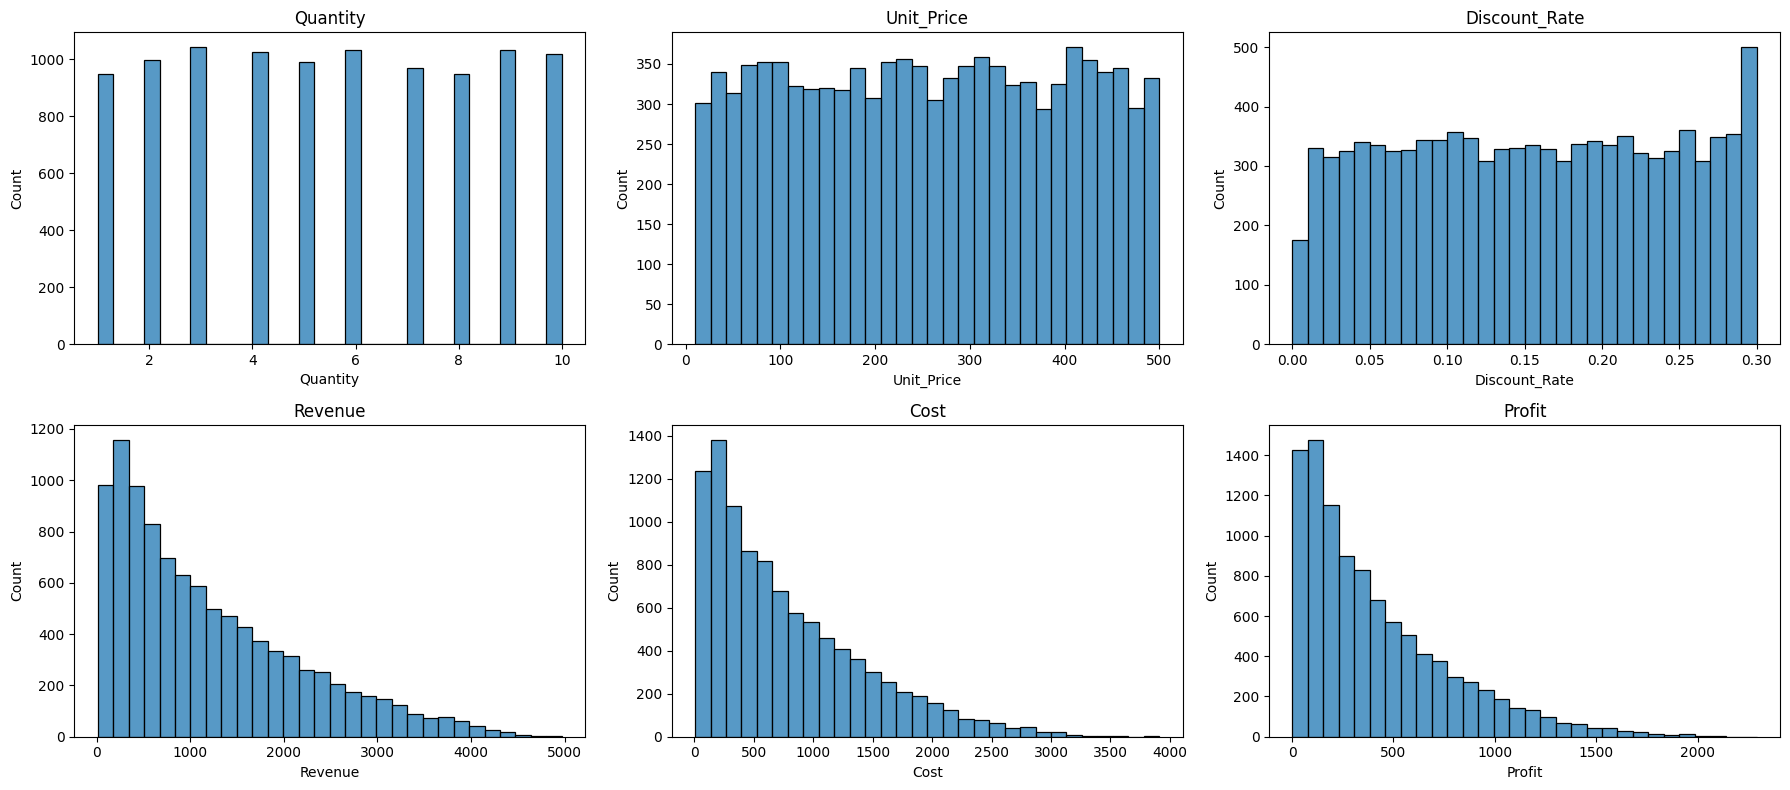

In [8]:
num_cols = ["Quantity", "Unit_Price", "Discount_Rate", 
            "Revenue", "Cost", "Profit"]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], ax=ax, bins=30)
    ax.set_title(col)

plt.tight_layout()
plt.show()

We see that this is a synthetic dataset where Revenue, Cost, and Profit follow similar distributions. On the Discount Rate side, it appears to be clipped around the 0.3 threshold.

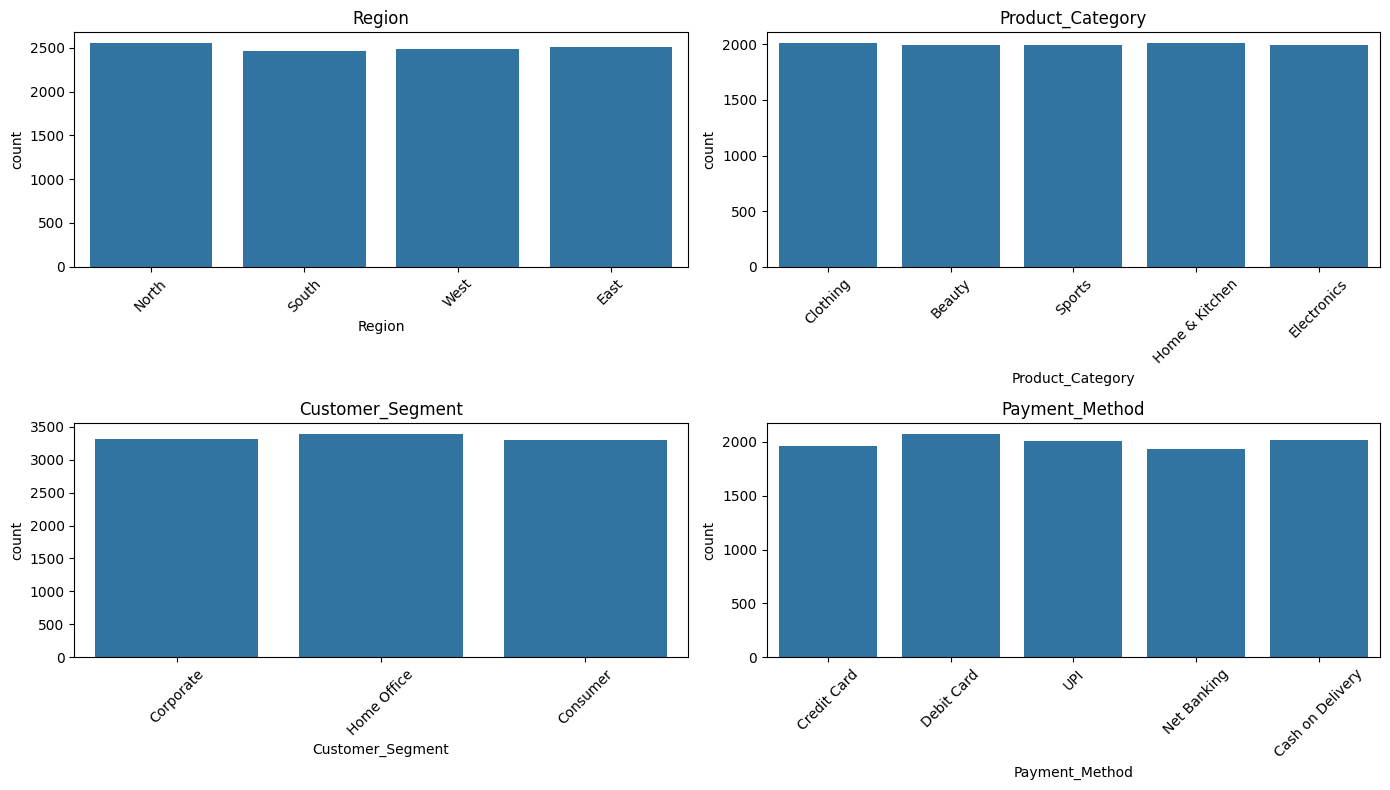

In [9]:
cat_cols = ["Region", "Product_Category", 
            "Customer_Segment", "Payment_Method"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(x=col, data=df, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

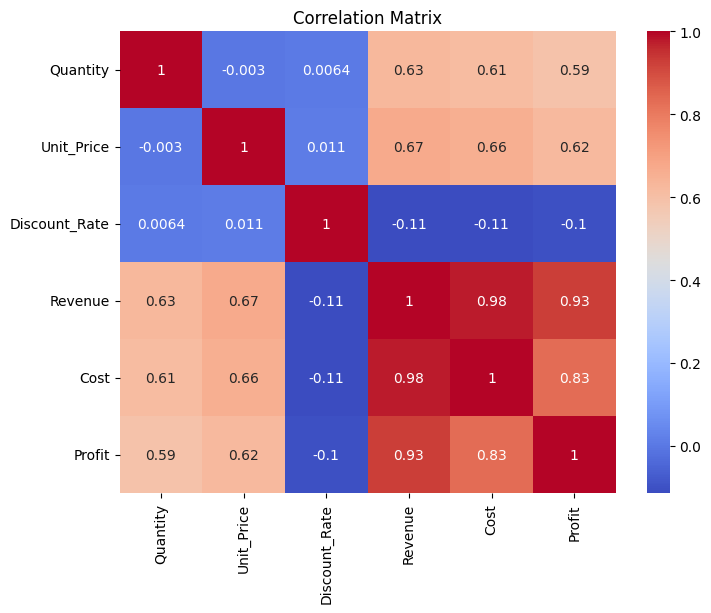

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop(columns=['Order_ID','Day_of_Month']).corr(numeric_only=True), 
            annot=True, 
            cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In the correlation matrix, we see a very high correlation between Revenue and Cost, and also a high correlation between Revenue, Cost, and Profit.

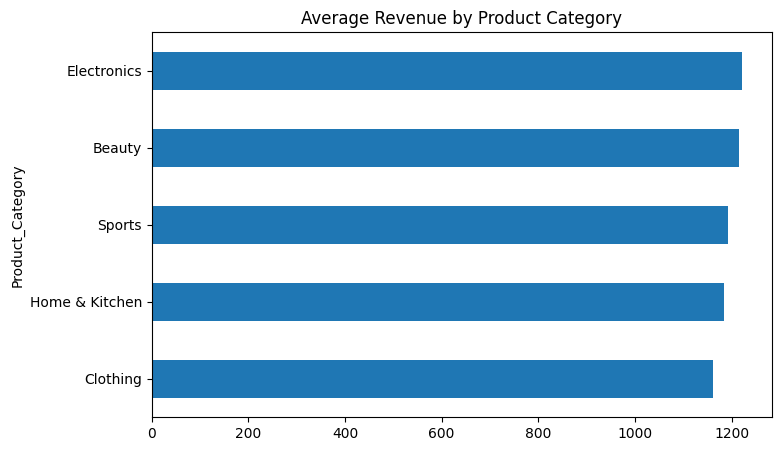

In [11]:
plt.figure(figsize=(8,5))
df.groupby("Product_Category")["Revenue"].mean().sort_values().plot(kind="barh")
plt.title("Average Revenue by Product Category")
plt.show()

When we look at the distribution of Revenues by product category, we again see a balanced distribution.

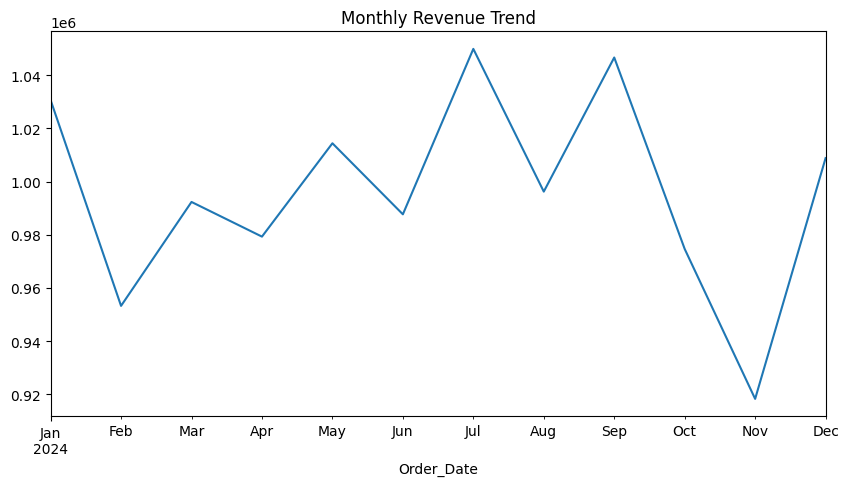

In [12]:
monthly = df.resample("ME", on="Order_Date")["Revenue"].sum()

monthly.plot(figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.show()

Looking at monthly Revenue amounts, we also see an almost equal distribution. There are no significant insights to be found here either.

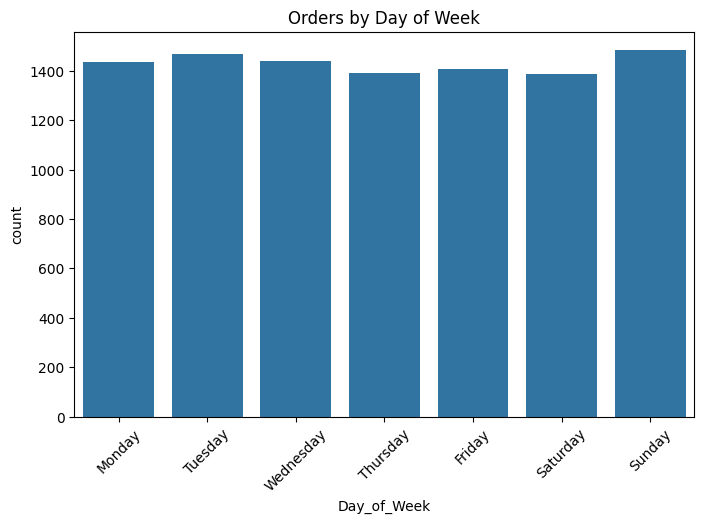

In [13]:
plt.figure(figsize=(8,5))

order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

sns.countplot(
    x="Day_of_Week",
    data=df,
    order=order
)

plt.title("Orders by Day of Week")
plt.xticks(rotation=45)
plt.show()

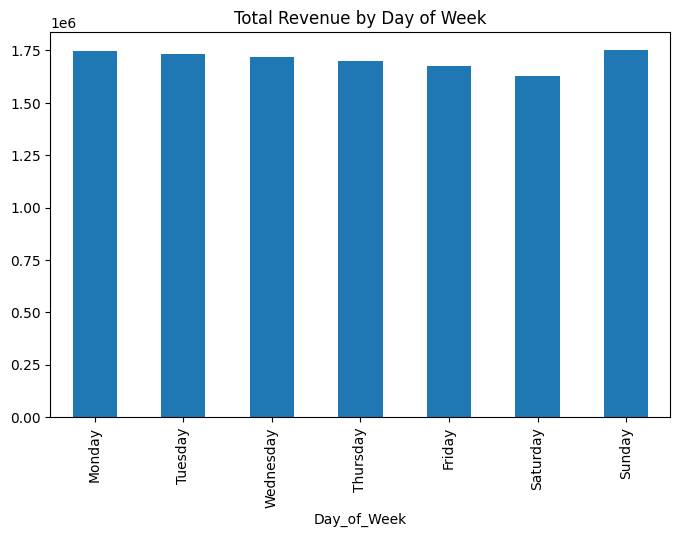

In [14]:
df.groupby("Day_of_Week")["Revenue"].sum().reindex(order).plot(kind="bar", figsize=(8,5))
plt.title("Total Revenue by Day of Week")
plt.show()

When we look at days of the week, there is no difference in terms of either revenue or number of orders.

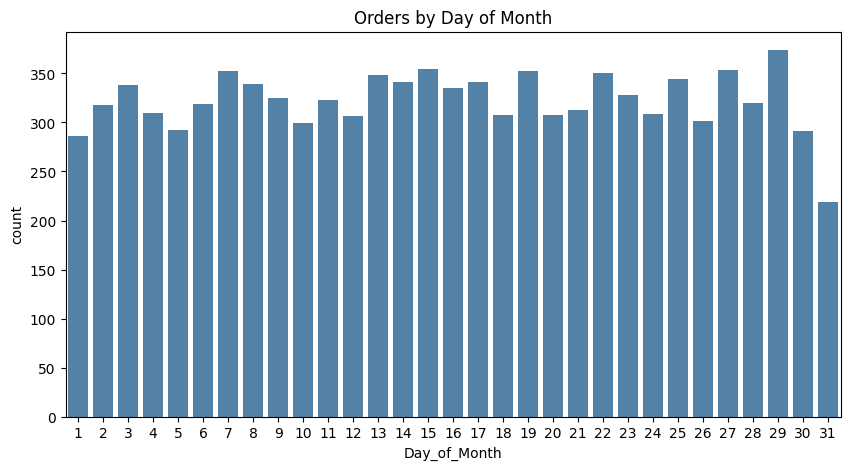

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="Day_of_Month",
    data=df,
    color="steelblue"
)

plt.title("Orders by Day of Month")
plt.show()

There is no meaningful pattern in day of month either. The 31st day naturally appears with fewer orders.

count    5994.000000
mean        1.668335
std         0.881295
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         9.000000
dtype: float64

<Axes: >

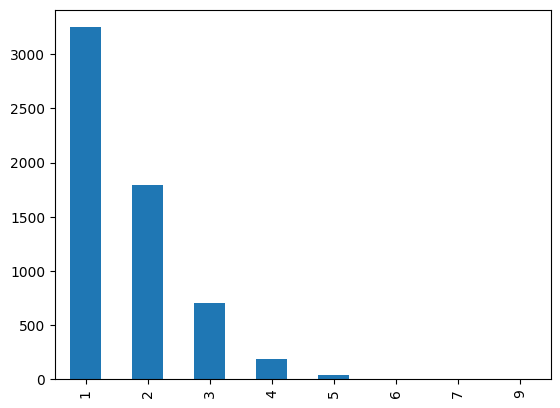

In [16]:
customer_orders = df.groupby("Customer_ID").size()
display(customer_orders.describe())
customer_orders.value_counts().sort_index().plot(kind="bar")

When we look at customers' total orders over the past year, we see that most customers place a single order, with a maximum of 9 orders from some customers.

<Axes: xlabel='Customer_Segment'>

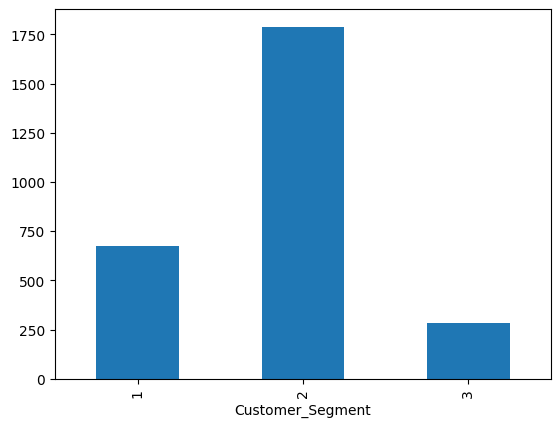

In [17]:
customer_frequency = df['Customer_ID'].value_counts()
more_than_one_order_df = df[df['Customer_ID'].isin(customer_frequency[customer_frequency > 1].index.tolist())]

(more_than_one_order_df
 .groupby('Customer_ID')['Customer_Segment']
 .nunique()
 .value_counts()
 .sort_index()
 .plot(kind="bar")
)

Most customers who placed multiple orders appear in more than one segment, while the number of customers belonging to a single segment is very low.

<Axes: xlabel='Customer_Segment'>

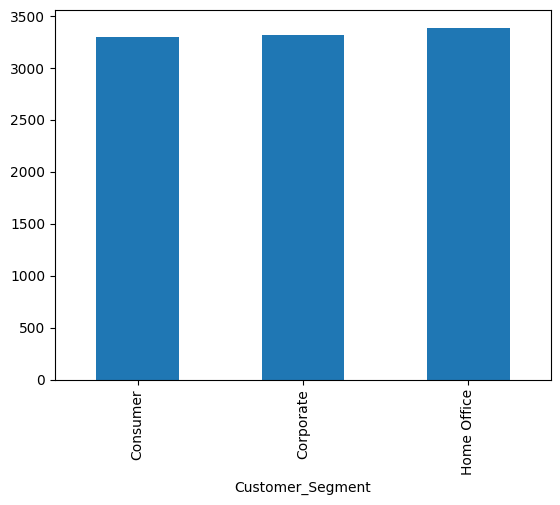

In [18]:
df.groupby("Customer_Segment").size().plot(kind="bar")

<Axes: xlabel='Product_Category', ylabel='Profit_Margin'>

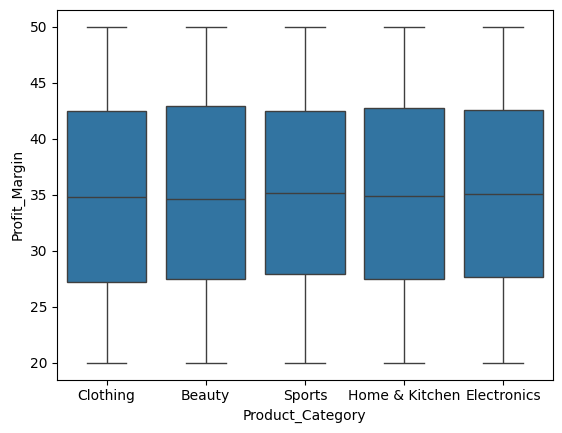

In [19]:
df["Profit_Margin"] = (df["Profit"] / df["Revenue"]) * 100
sns.boxplot(x="Product_Category", y="Profit_Margin", data=df)

Profit margin analysis shows consistent ranges across all product categories . No category significantly outperforms others in terms of profitability, which is another indicator of synthetic data generation.

In [20]:
customer_revenue = df.groupby("Customer_ID")["Revenue"].sum().sort_values(ascending=False)
cumulative = customer_revenue.cumsum() / customer_revenue.sum()
print(f"80 percent of the orders are ordered by {round(cumulative[cumulative < 0.8].shape[0] / cumulative.shape[0] * 100,2)} percent of the customers")

80 percent of the orders are ordered by 48.7 percent of the customers


Eighty percent of orders were placed by fifty percent of customers, so we don't see a major inequality here either.

# CONCLUSION & SUMMARY

## Key Findings:

### 1. Evidence Indicating Synthetic Data:
- **Perfectly balanced distributions**: Almost equal observation counts across all categories (Region, Product_Category, Customer_Segment).

### 2. Customer Behavior:
- Most customers placed a single order.
- Maximum number of orders: 9.
- Customers with multiple orders generally shopped across different segments.

### 3. Time-Based Analysis:
- No significant trend in monthly revenue (expected with synthetic data).
- No concentration of orders on specific days of the week.
- The 31st day of the month naturally has fewer orders.

### 4. Pareto Analysis:
- 80% of orders were placed by 50% of customers.
- This differs from the real-world Pareto principle (80/20), showing a more egalitarian distribution.

## Limitations:
- Since the data is synthetic, it's not possible to extract real business insights.
- This analysis is primarily focused on understanding the structure of the data.